# Basic setup to develop fitting interface

In [65]:
%reset -f
%run setup_notebook.py
from importlib import reload
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import numpy as np
from like3 import pixel_table as _pt; reload(_pt)
PixelTable = _pt.PixelTable
from like3 import sourcelist as _sl; reload(_sl)
SourceModel = _sl.SourceModel
from like3 import main as _main; reload(_main)
FermiFit = _main.FermiFit

In [66]:
source_name = 'Mrk 501'
source_model = SourceModel.from_fermi_catalog(source_name)
selected_source_name = source_model.selected_source.name
selected_source_name
pt = PixelTable('files/kerr/toby_v4.fits', source_model=source_model)

Loaded Fermi 4FGL gll_psc_v40.fit: 7224 entries
Loaded pixel table from "files/kerr/toby_v4.fits":
            42 bands Band(0, 4): PSF0@1.33 GeV nside 64 occ 1.001 ... Band(3, 11): PSF3@74.99 GeV nside 2048 occ 0.000
            193,317,496 photons
            8,240,918 pixels, order ring
            
Attached source model with 2 sources to pixel table
set_psf: 72 PSF entries (FRONT, BACK, PSF0, PSF1, PSF2, PSF3) from 'files/loc'


In [54]:
SkyCoord.from_name(source_name)

<SkyCoord (ICRS): (ra, dec) in deg
    (253.46756952, 39.76016913)>

In [67]:
ff = FermiFit(pt, verbose=False) ; 
ff.fit()

33 calls: improvement, quality: 7587.08, -0.00


In [56]:
ff.fit_info

{'calls': 33,
 'sigmas': array([0.03 , 0.021, 0.005, 0.009]),
 'cor': array([[ 100., -100.,  -40.,  -30.],
        [-100.,  100.,   40.,   30.],
        [ -40.,   40.,  100.,   40.],
        [ -30.,   30.,   40.,  100.]]),
 'deltaTS': 15174.2,
 'mask_indeces': array([0, 1, 2, 3]),
 'qual': -0.0}

5 calls: improvement, quality: 0.00, -0.00


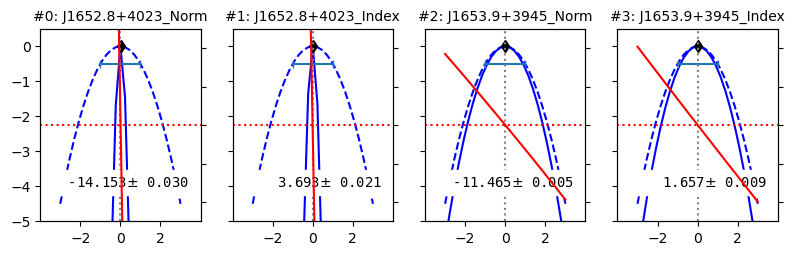

In [57]:
ff.fit(plot=True)

In [64]:
ff.summary()

Name                  index     value  error(%)
J1652.8+4023_Norm         0 7.035e-15       6.9
            _Index        1     3.693       0.6
J1653.9+3945_Norm         2  3.43e-12       1.2
            _Index        3     1.657       0.5


In [68]:
ff.summary()

Name                  index     value  error(%)  gradient        TS
J1652.8+4023_Norm         0 7.035e-15       6.9       3.7     18206
            _Index        1     3.693       0.6       3.2          
J1653.9+3945_Norm         2 3.429e-12       1.2      -0.6     47624
            _Index        3     1.657       0.5      -0.6          


In [60]:
source_model[0]

like3.sources.PointSource: 
	name  : J1652.8+4023
	icrs  : (253.204, +40.388)
	model : LogParabola
				Norm      : (1 + 0.072 - 0.067) (avg = 0.069) 7.04e-15   
		Index     : (1 + 0.006 - 0.006) (avg = 0.006) 3.69       
		beta      : (1 + 0.000 - 0.000) (avg = 0.000) 0          (FROZEN)
		E_break   : (1 + 0.000 - 0.000) (avg = 0.000) 4.08e+03   (FROZEN)